In [2]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

seed = 42
n=5

df_results_grid_actions = pd.read_csv('C:/Users/Teresa/Documents/GitHub/navsim/tmp/tmpTeresa/resultados_grid/resultados_grid_PPO.csv')

In [3]:
def get_group(value):
    if "_hover" in value:
        return "Hover"
    elif "_reach" in value:
        return "Reach"

df_results_grid_actions["tarea"] = df_results_grid_actions["id_run_name"].apply(get_group)

In [4]:
df_copy = df_results_grid_actions.copy()
df_results_grid_actions.sample(n, random_state=seed)

,id_run_name,iteration,reward,tarea
304,ppo_random_hover_25,1500,-565.326032,Hover
501,ppo_random_hover_40,0,-45.874151,Hover
441,ppo_random_hover_35,1400,-735.476588,Hover
153,ppo_random_hover_12,900,-690.000065,Hover
503,ppo_random_hover_40,200,-2024.186269,Hover


``Me quedo con los 5 modelos con mayor reward de cada tarea``

In [5]:
df_results_grid_actions.set_index(['tarea','id_run_name'],inplace=True)
top5 = (
    df_results_grid_actions.groupby(level="tarea")
      .apply(lambda g: g.sort_values("reward", ascending=False).head(5))
)

# Eliminar el nivel adicional que introduce groupby+apply
top5.index = top5.index.droplevel(0)

top5

iteration    reward
tarea id_run_name                             
Hover ppo_random_hover_34        800  6.910227
      ppo_random_hover_34        900  3.148071
      ppo_random_hover_34        700  1.054725
      ppo_random_hover_34       1000 -0.497030
      ppo_random_hover_12       1500 -8.018478

``Muestro la reward media por experimento y acción: hay valores extremos``
Esto nos indica qué modelo, de media, tiene un mejor aprendizaje.

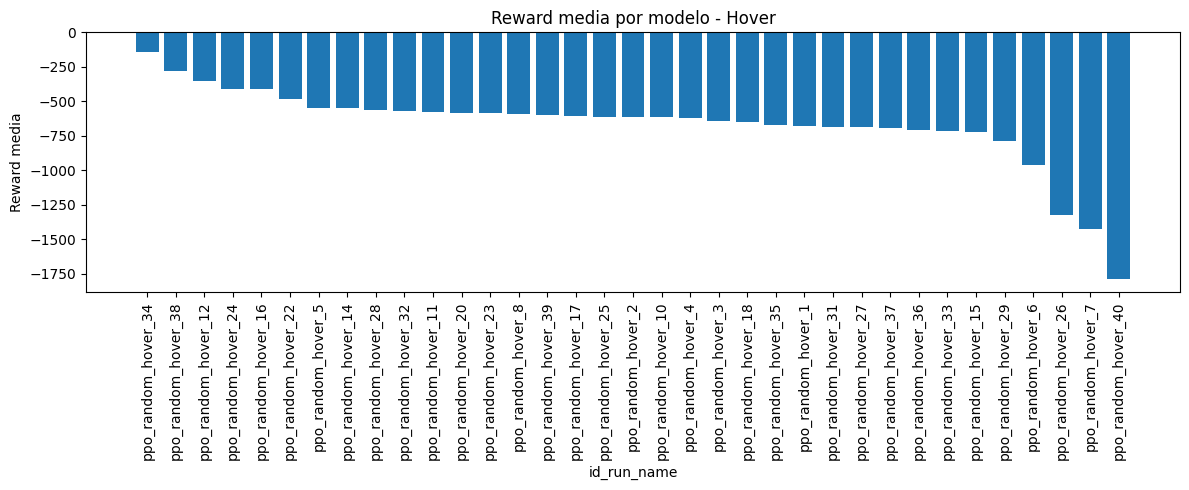

In [6]:
mean_rewards = df_results_grid_actions.groupby(["tarea", "id_run_name"])["reward"].mean()

for tarea, subdf in mean_rewards.groupby(level="tarea"):
    plt.figure(figsize=(12,5))
    
    # Convertir a DataFrame y resetear index para graficar
    plot_df = subdf.reset_index()
    plot_df = plot_df.sort_values("reward", ascending=False)
    
    plt.bar(plot_df["id_run_name"], plot_df["reward"])
    plt.title(f"Reward media por modelo - {tarea}")
    plt.xlabel("id_run_name")
    plt.ylabel("Reward media")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


``AUC``: Nos permite identificar qué modelo aprende con mayor rapidez, y obtiene mayor reward general a lo largo del 
entrenamiento. Mostraremos los 5 mejores para cada tarea.

In [7]:
auc_results = []

for (tarea, run_name), subdf in df_results_grid_actions.groupby(["tarea", "id_run_name"]):
    x = subdf["iteration"].values
    y = subdf["reward"].values
    
    # Área bajo la curva usando regla del trapecio
    auc = np.trapz(y, x)
    
    auc_results.append([tarea, run_name, auc])

auc_df = pd.DataFrame(auc_results, columns=["tarea", "id_run_name", "AUC"])

auc_df = auc_df.set_index(["tarea", "id_run_name"])

top5_auc = (
    auc_df.groupby(level="tarea")
          .apply(lambda g: g.sort_values("AUC", ascending=False).head(5))
)
top5_auc.index = top5_auc.index.droplevel(0)
top5_auc


AUC
tarea id_run_name                       
Hover ppo_random_hover_34 -224036.837638
      ppo_random_hover_14 -287705.016871
      ppo_random_hover_2  -387587.205284
      ppo_random_hover_38 -446763.415227
      ppo_random_hover_22 -523381.240160

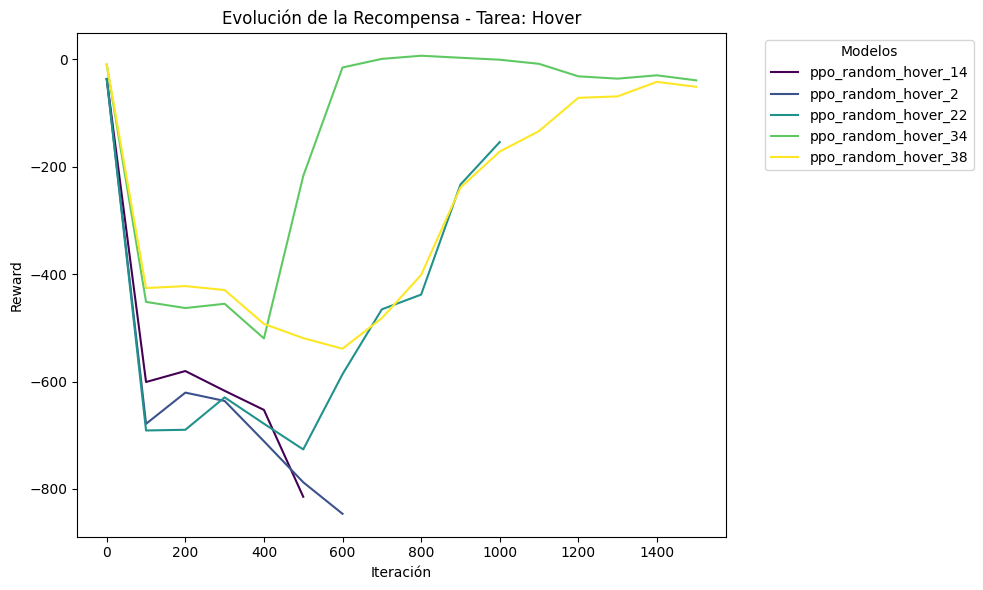

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Aseguramos que `top5_auc` tenga 'tarea' e 'id_run_name' como columnas, no solo en el índice
top5_auc_reset = top5_auc.reset_index()

# Convertir el índice jerárquico en columnas (para acceder a 'tarea' y 'id_run_name')
df_copy_reset = df_copy.reset_index()

# Unimos `top5_auc_reset` con `df_copy_reset` en las columnas comunes: 'tarea' y 'id_run_name'
merged_df = pd.merge(df_copy_reset, top5_auc_reset[['tarea', 'id_run_name']], on=['tarea', 'id_run_name'], how='inner')

# Usamos una lista de colores para asignar un color diferente a cada modelo
colors = plt.cm.viridis(np.linspace(0, 1, len(merged_df['id_run_name'].unique())))

# Ahora, procedemos a graficar
for tarea, task_df in merged_df.groupby('tarea'):
    plt.figure(figsize=(10, 6))
    
    # Iteramos sobre los modelos (id_run_name) para esta tarea
    for i, (run_name, subdf) in enumerate(task_df.groupby('id_run_name')):
        # Graficamos la evolución de la recompensa a lo largo de las iteraciones
        plt.plot(subdf['iteration'], subdf['reward'], label=run_name, color=colors[i])
    
    plt.xlabel('Iteración')
    plt.ylabel('Reward')
    plt.title(f'Evolución de la Recompensa - Tarea: {tarea}')
    plt.legend(title="Modelos", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



El modelo 34 es el mejor

In [10]:
'''
from isaaclab.utils import configclass
from isaaclab_rl.rsl_rl import RslRlOnPolicyRunnerCfg, RslRlPpoActorCriticCfg, RslRlPpoAlgorithmCfg

@configclass
class HoverPPORunnerCfg(RslRlOnPolicyRunnerCfg):
    num_steps_per_env = 24
    max_iterations = 1501
    save_interval = 100
    experiment_name = "hover"
    run_name = "ppo_random_hover_34"
    resume = False
    empirical_normalization = False
    policy = RslRlPpoActorCriticCfg(
        init_noise_std=0.2,
        actor_hidden_dims=[256, 256],
        critic_hidden_dims=[128, 128],
        activation="tanh",
    )
    algorithm = RslRlPpoAlgorithmCfg(
        value_loss_coef=0.5,
        use_clipped_value_loss=True,
        clip_param=0.2,
        entropy_coef=0.01,
        num_learning_epochs=8,
        num_mini_batches=8,
        learning_rate=0.001,
        schedule="adaptive",
        gamma=0.95,
        lam=0.95,
        desired_kl=0.01,
        max_grad_norm=1.0,
    )
'''

'\nfrom isaaclab.utils import configclass\nfrom isaaclab_rl.rsl_rl import RslRlOnPolicyRunnerCfg, RslRlPpoActorCriticCfg, RslRlPpoAlgorithmCfg\n\n@configclass\nclass HoverPPORunnerCfg(RslRlOnPolicyRunnerCfg):\n    num_steps_per_env = 24\n    max_iterations = 1501\n    save_interval = 100\n    experiment_name = "hover"\n    run_name = "ppo_random_hover_34"\n    resume = False\n    empirical_normalization = False\n    policy = RslRlPpoActorCriticCfg(\n        init_noise_std=0.2,\n        actor_hidden_dims=[256, 256],\n        critic_hidden_dims=[128, 128],\n        activation="tanh",\n    )\n    algorithm = RslRlPpoAlgorithmCfg(\n        value_loss_coef=0.5,\n        use_clipped_value_loss=True,\n        clip_param=0.2,\n        entropy_coef=0.01,\n        num_learning_epochs=8,\n        num_mini_batches=8,\n        learning_rate=0.001,\n        schedule="adaptive",\n        gamma=0.95,\n        lam=0.95,\n        desired_kl=0.01,\n        max_grad_norm=1.0,\n    )\n'

Comando de ejecución:
C:/Users/Teresa/Desktop/RuralData/IsaacLab/IsaacLab/isaaclab.bat -p C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/rl_v5_1_0/rsl_rl/train.py --task Isaac-Hover-Aerotaxi-RANDOM-34 --num_envs 8196 --checkpoint C:\Users\Teresa\Documents\GitHub\navsim\logs\rsl_rl\hover\2025-12-01_21-55-23_ppo_random_hover_34\model_800.pt